# scintegration Package - Example Usage

This notebook demonstrates how to use the `scintegration` package to evaluate single-cell data integration quality.

**What is scintegration?**
- Measures how well batch effects are removed while preserving biological signal
- Compares embeddings from different integration methods
- Provides a unified integration score: (Biology Preserved - Batch Leaked) / (2 × (Biology + Batch))

**In this example:**
- Dataset: Bone marrow cells from Tabula Sapiens v2
- Model: Pretrained scVI (trained on 63M cells from Cell Census)
- Evaluation: Compare biology preservation vs. batch removal

## Step 1: Install and Import Required Packages

In [1]:
# Install scintegration package 
# !pip install scintegration

# Import required libraries
import numpy as np
import pandas as pd
from pathlib import Path
import os
import warnings
warnings.simplefilter("ignore")

# Import scintegration components
from scintegration import (
    IntegrationScoreEvaluator,
    plot_metric_heatmap,
    plot_metric_summary,
    configure_logging, 
    analyze_label_distribution
)

# Import dataset and model utilities
from czbenchmarks.datasets import load_dataset
from czbenchmarks.datasets.single_cell_labeled import SingleCellLabeledDataset
import scvi

## Step 1.1: Set Random Seed for Reproducibility

Setting random seeds ensures that results are reproducible across different runs.

In [2]:
import os, random, torch
from lightning.pytorch import seed_everything

SEED = 42

# Python, NumPy, PyTorch seeds
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# scVI + Lightning seeds
scvi.settings.seed = SEED
seed_everything(SEED, workers=True)

Seed set to 42
Seed set to 42


42

## Step 2: Load Dataset

We'll use the bone marrow dataset from Tabula Sapiens v2, which contains:
- ~8,000 cells from 3 donors
- 25 annotated cell types
- Multiple technical batches

In [3]:
# Load bone marrow dataset
dataset: SingleCellLabeledDataset = load_dataset("tsv2_bone_marrow")
adata = dataset.adata.copy()

# Extract labels
cell_type_labels = adata.obs['cell_type'].values  # Biology we want to preserve
donor_labels = adata.obs['donor_id'].values       # Batch effect we want to remove

print(f"Dataset loaded:")
print(f"Cells: {adata.shape[0]:,}")
print(f"Genes: {adata.shape[1]:,}")
print(f"Cell types: {len(np.unique(cell_type_labels))}")
print(f"Donors: {len(np.unique(donor_labels))}")

Dataset loaded:
Cells: 8,045
Genes: 26,167
Cell types: 25
Donors: 3


## Step 2.1: Check Data Quality 

Before running expensive benchmarks, let's use the new utility functions to:
1. **Enable logging** (`configure_logging`) - See what's happening inside the tasks
2. **Analyze label distribution** (`analyze_label_distribution`) - Check for rare cell types that might cause issues

This helps catch problems early and understand your data better

In [4]:
# 1. Enable logging to see detailed messages
configure_logging('INFO')  # Options: 'DEBUG', 'INFO', 'WARNING', 'ERROR', 'CRITICAL'

# 2. Analyze cell type distribution
analysis = analyze_label_distribution(
    labels=cell_type_labels,
    min_samples=5,  # Flag cell types with < 5 cells (important for 5-fold CV)
    label_name="Cell Type"
)

# 3. Print summary
print(f"\nTotal cell types:    {analysis['n_classes']}")
print(f"Total cells:         {analysis['n_samples']:,}")
print(f"Smallest class size: {analysis['min_class_size']} cells")
print(f"Largest class size:  {analysis['max_class_size']:,} cells")
print(f"Imbalance ratio:     {analysis['imbalance_ratio']:.1f}x")

if analysis['has_rare_classes']:
    print(f"WARNING: {len(analysis['rare_classes'])} rare cell type(s) detected")
    print(f"These have < {5} samples and may cause issues in cross-validation.")
    print(f"Rare cell types:")
    for cell_type in analysis['rare_classes']:
        count = analysis['class_counts'][cell_type]
        print(f"• {cell_type}: {count} cells")
    print(f"TIP: Use min_class_size parameter in tasks to filter these automatically")
else:
    print(f"All cell types have ≥ {5} samples - good for 5-fold cross-validation")

2026-03-07 18:38:25,577 - scintegration - INFO - Logging configured for 'scintegration' package at INFO level
2026-03-07 18:38:25,585 - scintegration.utils - INFO - 
Cell Type Distribution Analysis:
2026-03-07 18:38:25,585 - scintegration.utils - INFO -   Total Cell Types: 25
2026-03-07 18:38:25,585 - scintegration.utils - INFO -   Total samples: 8045
2026-03-07 18:38:25,585 - scintegration.utils - INFO -   Class size range: [1, 2003]
2026-03-07 18:38:25,585 - scintegration.utils - INFO -   Imbalance ratio: 2003.00x
2026-03-07 18:38:25,585 - scintegration.utils - WARNING -   ⚠️  4 rare classes (< 5 samples):
2026-03-07 18:38:25,593 - scintegration.utils - WARNING -     - basophil: 1 samples
2026-03-07 18:38:25,593 - scintegration.utils - WARNING -     - endothelial cell: 2 samples
2026-03-07 18:38:25,593 - scintegration.utils - WARNING -     - non-classical monocyte: 3 samples
2026-03-07 18:38:25,593 - scintegration.utils - WARNING -     - plasmacytoid dendritic cell: 2 samples



Total cell types:    25
Total cells:         8,045
Smallest class size: 1 cells
Largest class size:  2,003 cells
Imbalance ratio:     2003.0x
These have < 5 samples and may cause issues in cross-validation.
Rare cell types:
• basophil: 1 cells
• endothelial cell: 2 cells
• non-classical monocyte: 3 cells
• plasmacytoid dendritic cell: 2 cells
TIP: Use min_class_size parameter in tasks to filter these automatically


## Step 2.2: Create Batch Column for scVI

The pretrained scVI model expects a `batch` column in the dataset. We'll create this by combining dataset, assay, and donor information.

In [5]:
import functools

# Create batch column: combine dataset_id, assay, suspension_type, and donor_id
# This matches the format expected by the pretrained scVI model
required_obs_keys = ["dataset_id", "assay", "suspension_type", "donor_id"]
adata.obs["batch"] = functools.reduce(
    lambda a, b: a + b, [adata.obs[c].astype(str) for c in required_obs_keys]
)

## Step 3: Load Pretrained scVI Model and Generate Embeddings

We'll use a pretrained scVI model (trained on 63M cells from CZ Cell Census) to generate embeddings.

**Note:** If you don't have the model yet, the cell below will automatically download it from the CZ Benchmarks S3 bucket. The model is approximately 500MB and may take a few minutes on first run.

In [6]:
# Configure path to your saved scVI model
# Change this path if your model is saved elsewhere
scvi_model_dir = Path("scvi_model_weights")  # Default location
# scvi_model_dir = Path("path/to/your/custom/scvi_model")  # Uncomment to use custom path

if not scvi_model_dir.exists() or not list(scvi_model_dir.iterdir()):
    print(f"scVI model not found at {scvi_model_dir}")
    import boto3
    from botocore import UNSIGNED
    from botocore.client import Config
    
    scvi_model_dir.mkdir(parents=True, exist_ok=True)
    print(f"   Created directory: {scvi_model_dir}")
    s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
    bucket_name = "cz-benchmarks-data"
    prefix = "models/v1/scvi_2023_12_15/homo_sapiens/"
    print("   Downloading model files from S3...")
    paginator = s3.get_paginator("list_objects_v2")
    file_count = 0
    for page in paginator.paginate(Bucket=bucket_name, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if not key.endswith("/"):
                local_path = scvi_model_dir / os.path.relpath(key, prefix)
                local_path.parent.mkdir(parents=True, exist_ok=True)
                s3.download_file(bucket_name, key, str(local_path))
                file_count += 1
    
    print(f"Downloaded {file_count} model files successfully")

# Prepare dataset for scVI (aligns gene names, etc.)
scvi.model.SCVI.prepare_query_anndata(adata, str(scvi_model_dir))

# Load the saved model
scvi_model = scvi.model.SCVI.load_query_data(adata, str(scvi_model_dir))
scvi_model.is_trained = True

# Generate embeddings using the loaded model
scvi_embeddings = scvi_model.get_latent_representation()

print(f"Embeddings generated: {scvi_embeddings.shape}")

INFO     File scvi_model_weights\model.pt already downloaded                                                       
INFO     Found 51.2625% reference vars in query data.                                                              
INFO     File scvi_model_weights\model.pt already downloaded                                                       
Embeddings generated: (8045, 50)


## Step 4: Evaluate Integration Quality with scintegration

Now we'll use the `scintegration` package to evaluate how well the scVI embeddings:
1. **Preserve biology** (cell types should cluster together)
2. **Remove batch effects** (donors should NOT cluster together)

The evaluator automatically computes all metrics and combines them into a single integration score.

### Four Core Metrics Used in Integration Score:

The integration score is computed from these 4 metrics (applied to both biology and batch):

1. **ARI (Adjusted Rand Index)** [0, 1] - Clustering agreement with labels
2. **NMI (Normalized Mutual Information)** [0, 1] - Information shared between clusters and labels
3. **Silhouette Score** [0, 1] - Cluster cohesion and separation
4. **F1 Score** [0, 1] - Classification performance (macro-averaged)

*Note: Additional metrics (Accuracy, AUROC, Precision, Recall) are computed for visualization but don't contribute to the integration score.*

### Integration Score Formula:
```
B = average(ARI_bio, NMI_bio, Silhouette_bio, F1_bio)
L = average(ARI_batch, NMI_batch, Silhouette_batch, F1_batch)

Integration Score = (B - L) / (2 × (B + L))
```

where B = Biology score and L = Leakage score

### Option 1: Run Evaluator with Default Parameters

In [7]:
# Create evaluator and calculate integration score
# This automatically computes all metrics (clustering, embedding, classification) for both biology preservation and batch removal
evaluator = IntegrationScoreEvaluator()
results = evaluator.evaluate_embeddings(
    embeddings=scvi_embeddings,
    obs=adata.obs,
    biology_labels=cell_type_labels,
    batch_labels=donor_labels,
    model_name='scvi'
)

print(results.summary())

2026-03-07 18:38:36,246 - scintegration.tasks - INFO - Starting ClusteringTask with 8045 cells, 50 features
2026-03-07 18:39:06,876 - scintegration.tasks - INFO - Leiden clustering identified 24 clusters
2026-03-07 18:39:06,942 - scintegration.tasks - INFO - Clustering metrics: ARI=0.4103, NMI=0.6790
2026-03-07 18:39:06,942 - scintegration.tasks - INFO - Starting EmbeddingTask with 8045 cells, 50 features
2026-03-07 18:39:08,983 - scintegration.tasks - INFO - Silhouette score: 0.0901
2026-03-07 18:39:08,990 - scintegration.tasks - INFO - Starting MetadataLabelPredictionTask with 8045 samples
2026-03-07 18:39:08,990 - scintegration.tasks - INFO - Total classes before filtering: 25
2026-03-07 18:39:08,990 - scintegration.tasks - INFO - Total classes after filtering (min_class_size=10): 20
2026-03-07 18:39:09,005 - scintegration.tasks - INFO - Samples after filtering: 8031 / 8045 (99.8%)
2026-03-07 18:39:09,016 - scintegration.tasks - INFO - Found 20 classes, using 'macro' averaging for m

INTEGRATION SCORE RESULTS

#1 SCVI:
  Integration Score: +0.0476
  Biology (B):       0.6553
  Leakage (L):       0.5414
    Biology metrics: ARI=0.705, NMI=0.679, Sil=0.545, F1=0.692
    Batch metrics:   ARI=0.536, NMI=0.225, Sil=0.493, F1=0.913

🏆 BEST MODEL: SCVI (IS = +0.0476)


### Option 2: Custom Parameters with Evaluator

You can  pass custom parameters directly to `evaluate_embeddings()`. This gives you control over both classification and clustering settings while still using the convenient evaluator API:

**Classification Parameters:**
- `classification_n_folds`: Number of CV folds (default: 5)
- `classification_min_class_size`: Minimum samples per class (default: 10)

**Clustering Parameters:**
- `clustering_n_neighbors`: Number of neighbors for k-NN graph (default: 15)
- `clustering_resolution`: Leiden resolution parameter (default: 1.0)

This is ideal when you:
- Want to include rare cell types (reduce `min_class_size`)
- Need more/fewer clusters (adjust `resolution`)
- Want smoother clusters (increase `n_neighbors`)
- Still want the full evaluator workflow with all metrics + visualization support

In [8]:
# Example: Custom parameters for datasets with rare cell types
# These parameters affect both biology and batch classification tasks
evaluator_custom = IntegrationScoreEvaluator()
results_custom = evaluator_custom.evaluate_embeddings(
    embeddings=scvi_embeddings,
    obs=adata.obs,
    biology_labels=cell_type_labels,
    batch_labels=donor_labels,
    model_name='scvi',
    classification_min_class_size=5   # Lower threshold = include rare cell types
)

print(results_custom.summary())

2026-03-07 18:40:19,576 - scintegration.tasks - INFO - Starting ClusteringTask with 8045 cells, 50 features
2026-03-07 18:40:20,836 - scintegration.tasks - INFO - Leiden clustering identified 24 clusters
2026-03-07 18:40:20,884 - scintegration.tasks - INFO - Clustering metrics: ARI=0.4103, NMI=0.6790
2026-03-07 18:40:20,884 - scintegration.tasks - INFO - Starting EmbeddingTask with 8045 cells, 50 features
2026-03-07 18:40:22,378 - scintegration.tasks - INFO - Silhouette score: 0.0901
2026-03-07 18:40:22,378 - scintegration.tasks - INFO - Starting MetadataLabelPredictionTask with 8045 samples
2026-03-07 18:40:22,378 - scintegration.tasks - INFO - Total classes before filtering: 25
2026-03-07 18:40:22,378 - scintegration.tasks - INFO - Total classes after filtering (min_class_size=5): 21
2026-03-07 18:40:22,394 - scintegration.tasks - INFO - Samples after filtering: 8037 / 8045 (99.9%)
2026-03-07 18:40:22,401 - scintegration.tasks - INFO - Found 21 classes, using 'macro' averaging for me

INTEGRATION SCORE RESULTS

#1 SCVI:
  Integration Score: +0.0473
  Biology (B):       0.6546
  Leakage (L):       0.5414
    Biology metrics: ARI=0.705, NMI=0.679, Sil=0.545, F1=0.689
    Batch metrics:   ARI=0.536, NMI=0.225, Sil=0.493, F1=0.913

🏆 BEST MODEL: SCVI (IS = +0.0473)


### Option 3: Running Tasks Separately (Maximum Control)

If you need maximum flexibility beyond what the evaluator provides, you can run tasks individually. This is useful when:
- You want to run only specific tasks (e.g., classification without clustering)
- You need different parameters for biology vs batch tasks (e.g., different resolution for each)
- Building custom evaluation pipelines with non-standard workflows

**Note:** Running tasks separately means you won't get an `IntegrationScoreResults` object, so you'll need to handle visualization separately.

Below we demonstrate running classification and clustering tasks with custom parameters:

In [ ]:
# Running custom tasks with full control over each task separately
from scintegration import (
    MetadataLabelPredictionTask, MetadataLabelPredictionTaskInput,
    ClusteringTask, ClusteringTaskInput
)

# Example 1: Custom classification task
custom_classification_input = MetadataLabelPredictionTaskInput(
    labels=cell_type_labels,
    n_folds=10,           # 10-fold cross-validation
    min_class_size=10,    # Filter classes with < 10 samples
)
classification_task = MetadataLabelPredictionTask()
classification_results = classification_task.run(scvi_embeddings, custom_classification_input)
print(f"Got {len(classification_results)} classification metrics")
for result in classification_results[:3]:
    print(f"  • {result.metric_type.name} = {result.value:.4f}")

# Example 2: Custom clustering task
custom_clustering_input = ClusteringTaskInput(obs=adata.obs, input_labels=cell_type_labels)
clustering_task = ClusteringTask(
    n_neighbors=25,      # CUSTOM: More neighbors for smoother clusters
    resolution=0.5       # CUSTOM: Lower resolution for coarser clustering
)
clustering_results = clustering_task.run(scvi_embeddings, custom_clustering_input)
print(f"Got {len(clustering_results)} clustering metrics")
for result in clustering_results:
    print(f"  • {result.metric_type.name} = {result.value:.4f}")

2026-03-07 18:41:31,022 - scintegration.tasks - INFO - Starting MetadataLabelPredictionTask with 8045 samples
2026-03-07 18:41:31,022 - scintegration.tasks - INFO - Total classes before filtering: 25
2026-03-07 18:41:31,022 - scintegration.tasks - INFO - Total classes after filtering (min_class_size=10): 20
2026-03-07 18:41:31,033 - scintegration.tasks - INFO - Samples after filtering: 8031 / 8045 (99.8%)
2026-03-07 18:41:31,037 - scintegration.tasks - INFO - Found 20 classes, using 'macro' averaging for metrics
2026-03-07 18:41:31,037 - scintegration.tasks - INFO - Using 10-fold stratified cross-validation with random_seed=42
2026-03-07 18:41:31,037 - scintegration.tasks - INFO - Created classifiers: ['lr', 'knn', 'rf']
2026-03-07 18:41:31,042 - scintegration.tasks - INFO - Running cross-validation for lr...
2026-03-07 18:41:57,202 - scintegration.tasks - INFO - Running cross-validation for knn...
2026-03-07 18:41:57,647 - scintegration.tasks - INFO - Running cross-validation for rf..

Got 20 classification metrics
  • MEAN_FOLD_F1_SCORE = 0.6930
  • MEAN_FOLD_ACCURACY = 0.8637
  • MEAN_FOLD_PRECISION = 0.7273


2026-03-07 18:43:01,934 - scintegration.tasks - INFO - Leiden clustering identified 13 clusters
2026-03-07 18:43:01,974 - scintegration.tasks - INFO - Clustering metrics: ARI=0.5026, NMI=0.7002


✓ Got 2 clustering metrics
  • ADJUSTED_RAND_INDEX = 0.5026
  • NORMALIZED_MUTUAL_INFO = 0.7002


## Step 5: Visualize Results

The scintegration package provides three built-in visualization functions:

1. **`plot_metric_heatmap()`** - Biology vs Batch breakdown for each metric
2. **`plot_model_comparison()`** - Compare Integration Score, Biology Score, and Leakage Score across models
3. **`plot_metric_summary()`** - Combined view with model ranking and detailed metric breakdown

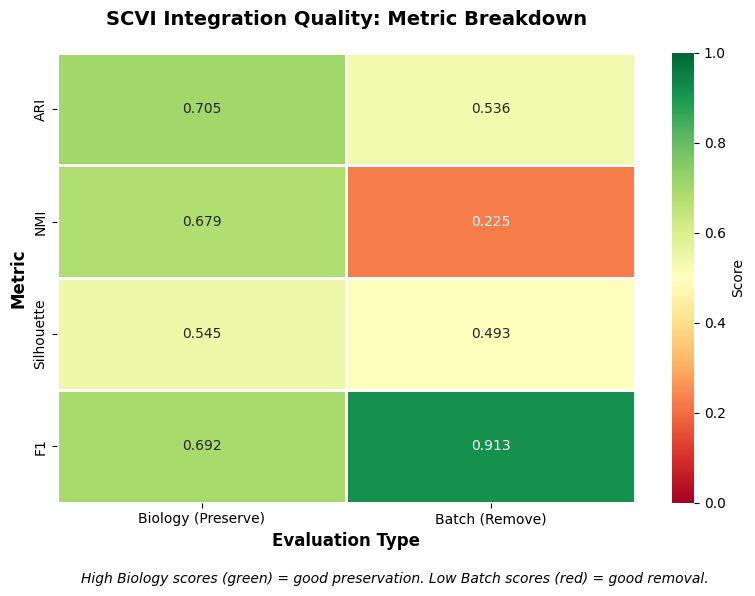

In [10]:
# 1. Metric Heatmap - Shows Biology vs Batch for each of the 4 core metrics
plot_metric_heatmap(results, model_names='scvi')

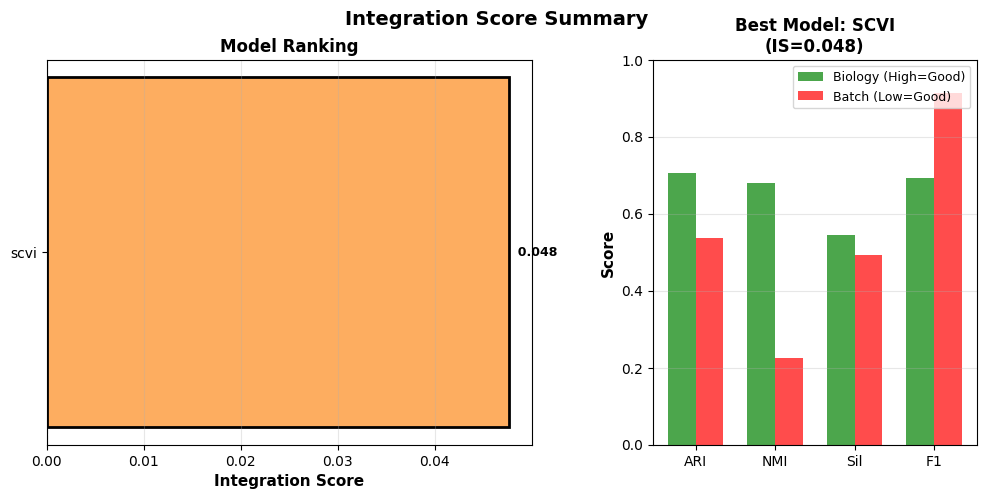

In [11]:
# 3. Metric Summary - Combined view with ranking and detailed breakdown
plot_metric_summary(results)

## Step 6: Export Metrics to CSV

The scintegration package provides a convenient method to export all calculated metrics to a CSV file. This includes:
- Integration Score, Biology Score (B), and Leakage Score (L)
- All core metrics: ARI, NMI, Silhouette, F1 (for both biology and batch)
- Additional classification metrics: Accuracy, Precision, Recall, AUROC 

The exported file is automatically named with the date and time for easy tracking of experiments.

In [ ]:
# Export metrics to CSV file
# The file will be named: integration_metrics_{model_name}_YYYY-MM-DD.csv

csv_path = results.to_csv(output_dir=".")

print(f"Metrics exported successfully!")
print(f"File saved to: {csv_path}")

# You can also view the data as a DataFrame before exporting
df = results.to_dataframe()
print(f"\nDataFrame preview:")
print(df)

## Summary

This notebook demonstrated:
1. Loading a single-cell dataset
2. Generating embeddings with pretrained scVI
3. Using `scintegration` to evaluate integration quality with one simple method call
4. Visualizing results with three different plot types

### Key Takeaways:
- **Simple API**: One call to `evaluate_embeddings()` runs all metrics automatically
- **Comprehensive Metrics**: ARI, NMI, Silhouette, F1 for both biology and batch
- **Flexible Visualization**: Three plot types for different analysis needs

### Next Steps:
- Try with your own datasets and models
- Compare multiple integration methods
- Adjust integration parameters based on scores
- Use the results to select the best integration approach for your data

### Installation:
```bash
pip install scintegration
```

### Documentation:
See the `single-cell-integration-score/` directory for full API documentation.